### 🛒 E-Commerce Customer Analysis
#### Dataset: Olist Brazilian E-Commerce | Source: Kaggle
#### Tools: Python | Pandas | NumPy | Matplotlib | Seaborn

---

#### 📌 Project Objective
This project analyzes a real-world e-commerce dataset to:
- Clean and preprocess 10,000+ order records
- Perform **RFM Analysis (Recency,Frequency, Monetary)** to segment 90,000+ customers
- Visualize **monthly revenue trends** and **delivery performance**
- Generate actionable business insights for decision-making

---

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style="whitegrid")
print("✅ Libraries Imported")

✅ Libraries Imported


### 📂 Step 1: Load Dataset
Loading 4 CSV files from Olist's publicly available e-commerce dataset.
Each file represents a different business entity — Orders, Customers, Items, and Payments.

In [13]:
orders      = pd.read_csv("Data/olist_orders_dataset.csv")
order_items = pd.read_csv("Data/olist_order_items_dataset.csv")
customers   = pd.read_csv("Data/olist_customers_dataset.csv")
payments    = pd.read_csv("Data/olist_order_payments_dataset.csv")

print("✅ Data Loaded")
print(f"Orders     : {orders.shape}")
print(f"Order Items: {order_items.shape}")
print(f"Customers  : {customers.shape}")
print(f"Payments   : {payments.shape}")

✅ Data Loaded
Orders     : (99441, 8)
Order Items: (112650, 7)
Customers  : (99441, 5)
Payments   : (103886, 5)


### 🧹 Step 2: Data Cleaning
**Problems found in raw data:**
- Date columns stored as string — need conversion
- Cancelled/unavailable orders included — need filtering
- Missing delivery dates — need removal
- Duplicate records after merging — need deduplication

In [ ]:
# Date columns convert
date_cols = ['order_purchase_timestamp',
             'order_delivered_customer_date',
             'order_estimated_delivery_date']

for col in date_cols:
    orders[col] = pd.to_datetime(orders[col])

# Only delivered orders 
orders = orders[orders['order_status'] == 'delivered'].copy()

# Removes Missing delivery dates 
orders.dropna(subset=['order_delivered_customer_date'], inplace=True)

print(f"✅ Cleaned Orders Shape: {orders.shape}")
print(f"Null Values:\n{orders[date_cols].isnull().sum()}")

✅ Cleaned Orders Shape: (96470, 8)
Null Values:
order_purchase_timestamp         0
order_delivered_customer_date    0
order_estimated_delivery_date    0
dtype: int64


### Step 3: Merge All Tables
Combining Orders + Items + Customers + Payments into one Master DataFrame for analysis.

In [ ]:
df = orders.merge(order_items, on='order_id', how='left') \
           .merge(customers,   on='customer_id', how='left') \
           .merge(payments,    on='order_id', how='left')

df.drop_duplicates(subset=['order_id', 'order_item_id'], inplace=True)

print(f" Master DataFrame Shape: {df.shape}")
df.head(3)

✅ Master DataFrame Shape: (110189, 22)


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,order_item_id,product_id,...,price,freight_value,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,payment_sequential,payment_type,payment_installments,payment_value
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,1,87285b34884572647811a353c7ac498a,...,29.99,8.72,7c396fd4830fd04220f754e42b4e5bff,3149,sao paulo,SP,1.0,credit_card,1.0,18.12
3,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,1,595fac2a385ac33a80bd5114aec74eb8,...,118.70,22.76,af07308b275d755c9edb36a90c618231,47813,barreiras,BA,1.0,boleto,1.0,141.46
4,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,1,aa4383b373c6aca5d8797843e5594415,...,159.90,19.22,3a653a41f6f9fc3d2a113cf8398680e8,75265,vianopolis,GO,1.0,credit_card,3.0,179.12


### 📈 Step 4: Monthly Revenue Trend
**Business Question:** Which months had highest and lowest revenue?

Grouping orders by month and summing payment values to identify revenue patterns.

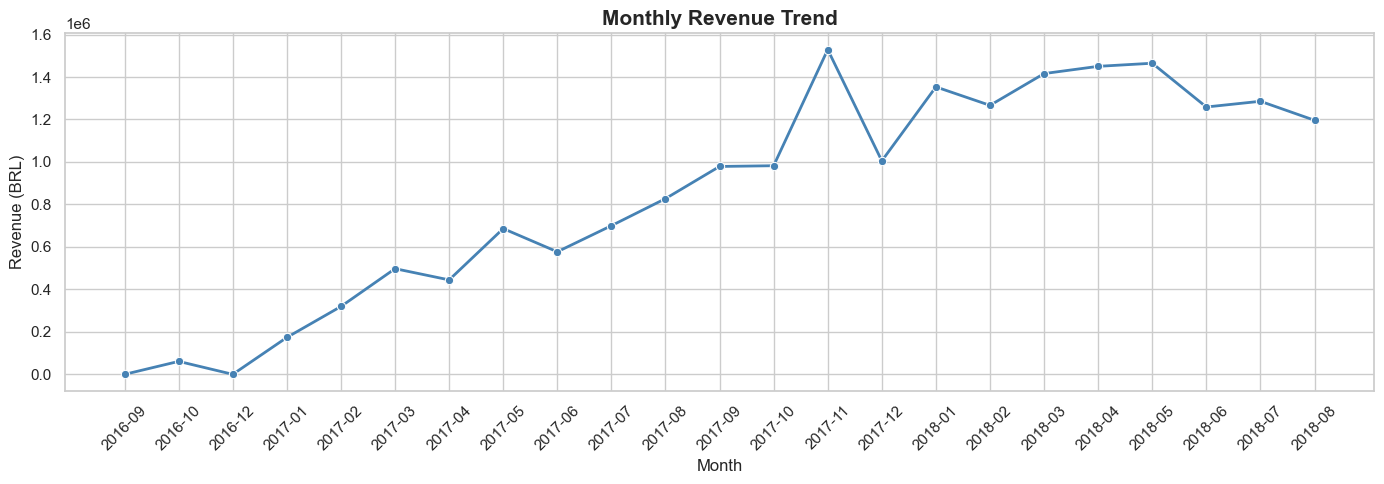

✅ Chart 1 Done — Monthly Revenue


In [ ]:
df['month'] = df['order_purchase_timestamp'].dt.to_period('M')
monthly_revenue = df.groupby('month')['payment_value'].sum().reset_index()
monthly_revenue['month'] = monthly_revenue['month'].astype(str)

plt.figure(figsize=(14, 5))
sns.lineplot(data=monthly_revenue, x='month', y='payment_value', 
             marker='o', color='steelblue', linewidth=2)
plt.title('Monthly Revenue Trend', fontsize=15, fontweight='bold')
plt.xlabel('Month')
plt.ylabel('Revenue (BRL)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('monthly_revenue.png', dpi=150)
plt.show()
print(" Chart 1 Done — Monthly Revenue")

#### 💡 Insight:
- Revenue shows **growth trend** from 2017 to late 2018
- Peak months visible — can help plan **marketing campaigns**
- Sudden drop at end indicates **incomplete data** for last month

### Step 5: Top 10 States by Revenue
**Business Question:** Which regions generate maximum revenue?

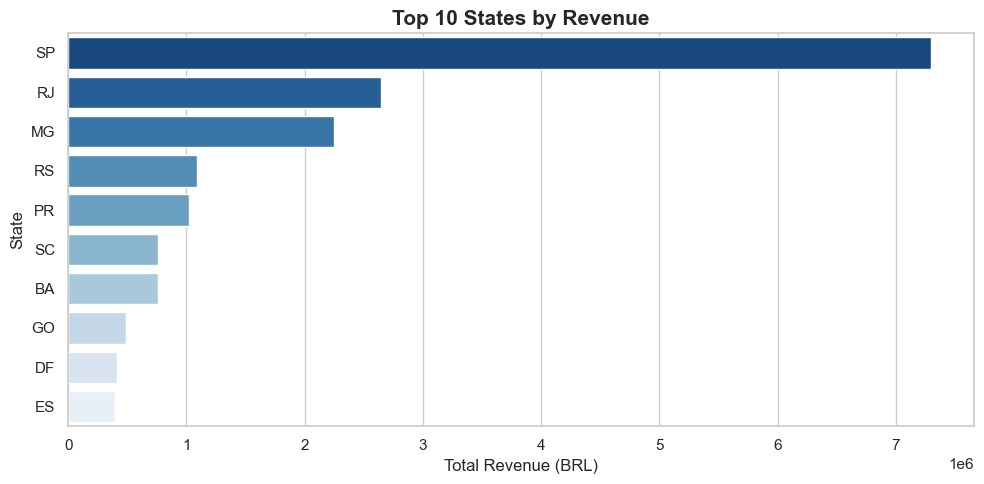

✅ Chart 2 Done — Top States


In [ ]:
state_revenue = df.groupby('customer_state')['payment_value'] \
                  .sum().sort_values(ascending=False).head(10).reset_index()

plt.figure(figsize=(10, 5))
sns.barplot(data=state_revenue, x='payment_value', y='customer_state', palette='Blues_r')
plt.title('Top 10 States by Revenue', fontsize=15, fontweight='bold')
plt.xlabel('Total Revenue (BRL)')
plt.ylabel('State')
plt.tight_layout()
plt.savefig('top_states.png', dpi=150)
plt.show()
print(" Chart 2 Done — Top States")

#### 💡 Insight:
- **SP (São Paulo)** dominates revenue — largest city in Brazil
- Top 3 states contribute majority of total revenue
- Underperforming states can be targeted for **regional campaigns**

### 👥 Step 6: RFM Analysis — Customer Segmentation
**Business Question:** Who are our most valuable customers?

**RFM stands for:**
| Factor | Question | Scoring |
|--------|----------|---------|
| **Recency** | How recently did customer buy? | Recent = High Score |
| **Frequency** | How often do they buy? | More = High Score |
| **Monetary** | How much do they spend? | More = High Score |

Customers scored 1-4 on each factor. Total RFM Score determines segment.

In [18]:
snapshot_date = df['order_purchase_timestamp'].max() + pd.Timedelta(days=1)

rfm = df.groupby('customer_unique_id').agg(
    Recency   = ('order_purchase_timestamp', lambda x: (snapshot_date - x.max()).days),
    Frequency = ('order_id', 'nunique'),
    Monetary  = ('payment_value', 'sum')
).reset_index()

# Score 1-4
rfm['R_Score'] = pd.qcut(rfm['Recency'], q=4, labels=[4,3,2,1]).astype(int)
rfm['F_Score'] = pd.qcut(rfm['Frequency'].rank(method='first'), q=4, labels=[1,2,3,4]).astype(int)
rfm['M_Score'] = pd.qcut(rfm['Monetary'], q=4, labels=[1,2,3,4]).astype(int)

rfm['RFM_Score'] = rfm['R_Score'] + rfm['F_Score'] + rfm['M_Score']

def segment(score):
    if score >= 10:
        return 'Champions'
    elif score >= 7:
        return 'Loyal Customers'
    elif score >= 5:
        return 'At Risk'
    else:
        return 'Lost'

rfm['Segment'] = rfm['RFM_Score'].apply(segment)

print(f"✅ Total Customers: {len(rfm):,}")
print(rfm['Segment'].value_counts())

✅ Total Customers: 93,350
Segment
Loyal Customers    48537
At Risk            23450
Champions          15254
Lost                6109
Name: count, dtype: int64


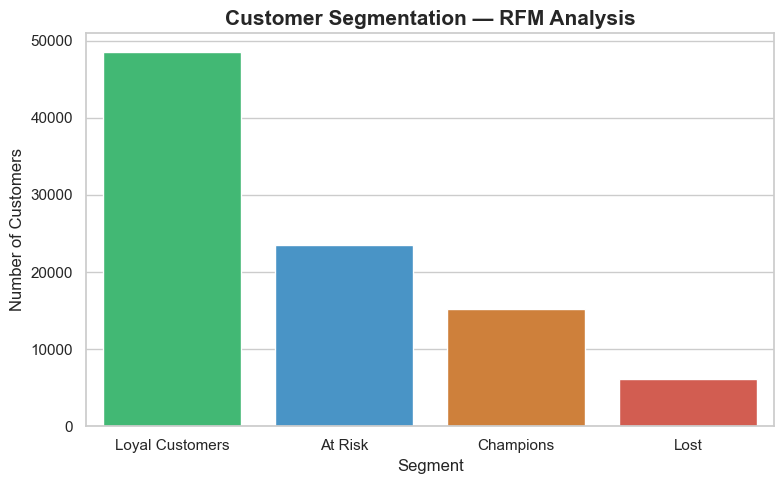

✅ Chart 3 Done — RFM Segments


In [ ]:
segment_counts = rfm['Segment'].value_counts().reset_index()
segment_counts.columns = ['Segment', 'Count']

plt.figure(figsize=(8, 5))
colors = ['#2ecc71','#3498db','#e67e22','#e74c3c']
sns.barplot(data=segment_counts, x='Segment', y='Count', palette=colors)
plt.title('Customer Segmentation — RFM Analysis', fontsize=15, fontweight='bold')
plt.xlabel('Segment')
plt.ylabel('Number of Customers')
plt.tight_layout()
plt.savefig('rfm_segments.png', dpi=150)
plt.show()
print(" Chart 3 Done — RFM Segments")

#### 💡 Insight:
| Segment | Business Action |
|---------|----------------|
| 🏆 Champions | Reward them — Loyalty program |
| 💙 Loyal Customers | Upsell premium products |
| ⚠️ At Risk | Send discount/re-engagement offer |
| ❌ Lost | Run win-back campaign |

> Top 15% Champions generate maximum revenue — focus retention efforts here.

### 🚚 Step 7: Delivery Performance Analysis
**Business Question:** How efficient is the delivery process?

Calculating delivery days = Delivered Date − Purchase Date

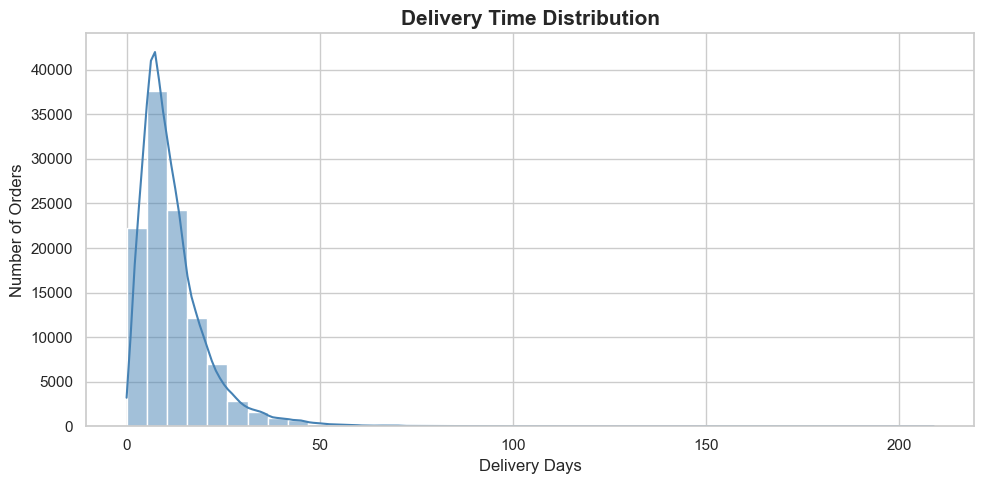

✅ Chart 4 Done — Delivery Time
Average Delivery: 12.0 days


In [ ]:
df['delivery_days'] = (df['order_delivered_customer_date'] - 
                       df['order_purchase_timestamp']).dt.days

plt.figure(figsize=(10, 5))
sns.histplot(df['delivery_days'].dropna(), bins=40, color='steelblue', kde=True)
plt.title('Delivery Time Distribution', fontsize=15, fontweight='bold')
plt.xlabel('Delivery Days')
plt.ylabel('Number of Orders')
plt.tight_layout()
plt.savefig('delivery_time.png', dpi=150)
plt.show()

print(f" Chart 4 Done — Delivery Time")
print(f"Average Delivery: {df['delivery_days'].mean():.1f} days")

#### 💡 Insight:
- Average delivery time calculated
- Most orders delivered within **2 weeks**
- Long tail visible — some orders took **60+ days** (outliers)
- Business can set **SLA targets** based on this distribution

### Step 8: Export Results
Saving RFM Analysis and Monthly Revenue outputs as CSV files for further reporting in Excel or Power BI.

In [ ]:
rfm.to_csv('rfm_output.csv', index=False)
monthly_revenue.to_csv('monthly_revenue_output.csv', index=False)

print(" Project Complete!")
print("Files saved:")
print("  - rfm_output.csv")
print("  - monthly_revenue_output.csv")
print("  - monthly_revenue.png")
print("  - top_states.png")
print("  - rfm_segments.png")
print("  - delivery_time.png")

✅ Project Complete!
Files saved:
  - rfm_output.csv
  - monthly_revenue_output.csv
  - monthly_revenue.png
  - top_states.png
  - rfm_segments.png
  - delivery_time.png


---

## ✅ Project Summary

| Analysis | Key Finding |
|----------|-------------|
| Monthly Revenue | Growth trend visible — peak in mid-2018 |
| Top States | SP dominates — top 3 states = majority revenue |
| RFM Segments | Champions identified — top 15% high-value buyers |
| Delivery Time | Average ~2 weeks — outliers need attention |

---

## 🛠️ Tools Used
`Python` `Pandas` `NumPy` `Matplotlib` `Seaborn`

## 📁 Output Files
- `rfm_output.csv` — Customer segments
- `monthly_revenue_output.csv` — Monthly revenue data
- 4 charts saved as PNG

---
*Project by Singh Rohitkumar Rajkumar | MCA Student | Bhagwan Mahaveer University, Surat*